In [1]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import struct
import heapq

import os
from collections import defaultdict

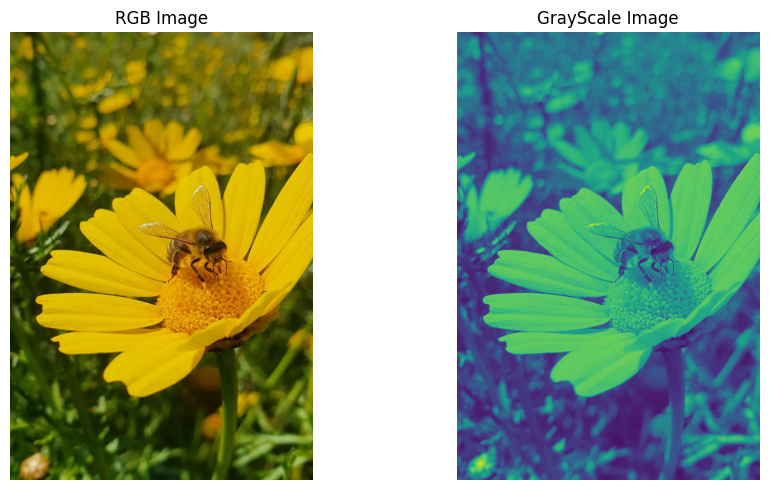

In [2]:
img_rgb = Image.open("1.jpeg")
img_gray = Image.open("1.jpeg").convert('L')

rgb_arr = np.array(img_rgb)
gray_arr = np.array(img_gray)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(rgb_arr)
axes[0].set_title('RGB Image')
axes[0].axis('off')

axes[1].imshow(gray_arr)
axes[1].set_title('GrayScale Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [3]:
def ColourSpace(img_arr):

    r = img_arr[:, :, 0].astype(np.float32)
    g = img_arr[:, :, 1].astype(np.float32)
    b = img_arr[:, :, 2].astype(np.float32)

    Y  = 0.299 * r + 0.587 * g + 0.114 * b
    Cb = -0.168736 * r - 0.331264 * g + 0.5 * b + 128
    Cr = 0.5 * r - 0.418688 * g - 0.081312 * b + 128

    Y  = np.clip(Y, 0, 255).astype(np.uint8)
    Cb = np.clip(Cb, 0, 255).astype(np.uint8)
    Cr = np.clip(Cr, 0, 255).astype(np.uint8)

    return Y, Cb, Cr


def ycbcr_to_rgb(Y, Cb, Cr):

    Y = Y.astype(np.float32)
    Cb = Cb.astype(np.float32) - 128
    Cr = Cr.astype(np.float32) - 128

    r = Y + 1.402 * Cr
    g = Y - 0.344136 * Cb - 0.714136 * Cr
    b = Y + 1.772 * Cb
    rgb = np.stack((r, g, b), axis=2)

    return np.clip(rgb, 0, 255).astype(np.uint8)


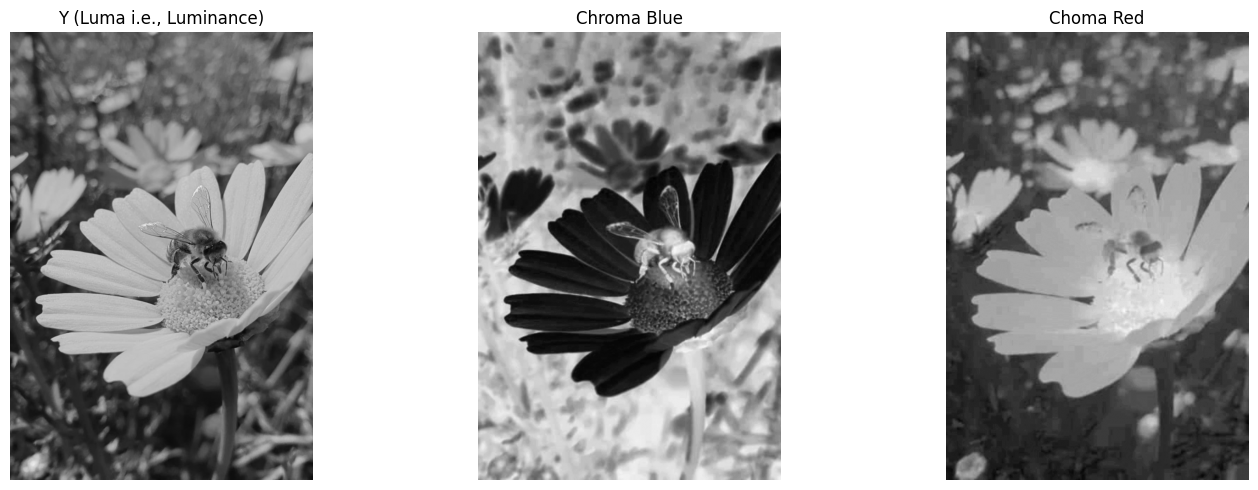

In [4]:
Y, Cb, Cr = ColourSpace(rgb_arr)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(Y, cmap='gray')
axes[0].axis("off")
axes[0].set_title("Y (Luma i.e., Luminance)")

axes[1].imshow(Cb, cmap='gray')
axes[1].set_title("Chroma Blue")
axes[1].axis("off")

axes[2].imshow(Cr, cmap='gray')
axes[2].set_title("Choma Red")
axes[2].axis("off")

plt.tight_layout()
plt.show()

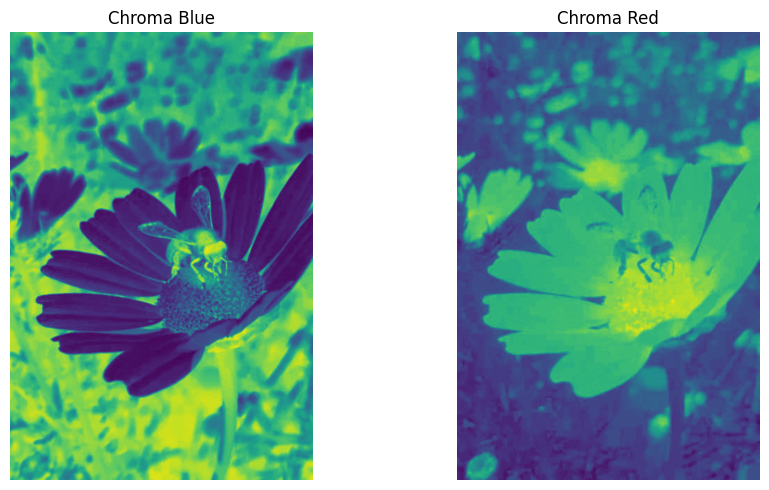

In [5]:
# viridis
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(Cb)
axes[0].set_title('Chroma Blue')
axes[0].axis('off')

axes[1].imshow(Cr)
axes[1].set_title('Chroma Red')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [6]:
def subsample_chroma(channel):
    h, w = channel.shape
    h_trim = (h // 2) * 2
    w_trim = (w // 2) * 2
    channel = channel[:h_trim, :w_trim]
    return channel.reshape(h//2, 2, w//2, 2).mean(axis=(1, 3)).astype(np.uint8)

def upsample_chroma(channel, target_shape):
    h_sub, w_sub = channel.shape
    h_target, w_target = target_shape
    up = np.repeat(np.repeat(channel, 2, axis=0), 2, axis=1)
    return up[:h_target, :w_target]


## **Averaging 2x2 chroma blocks** works because the human eye perceives brightness sharply but color poorly, so discarding 75% of color data via averaging creates smooth, natural results

In [7]:
Cb_sub = subsample_chroma(Cb).astype(np.uint8)
Cr_sub = subsample_chroma(Cr).astype(np.uint8)

# Upsample them back to original size
Cb_up = upsample_chroma(Cb_sub, Cb.shape).astype(np.uint8)
Cr_up = upsample_chroma(Cr_sub, Cr.shape).astype(np.uint8)

# img_reconstructed
img_redo = ycbcr_to_rgb(Y, Cb_up, Cr_up)

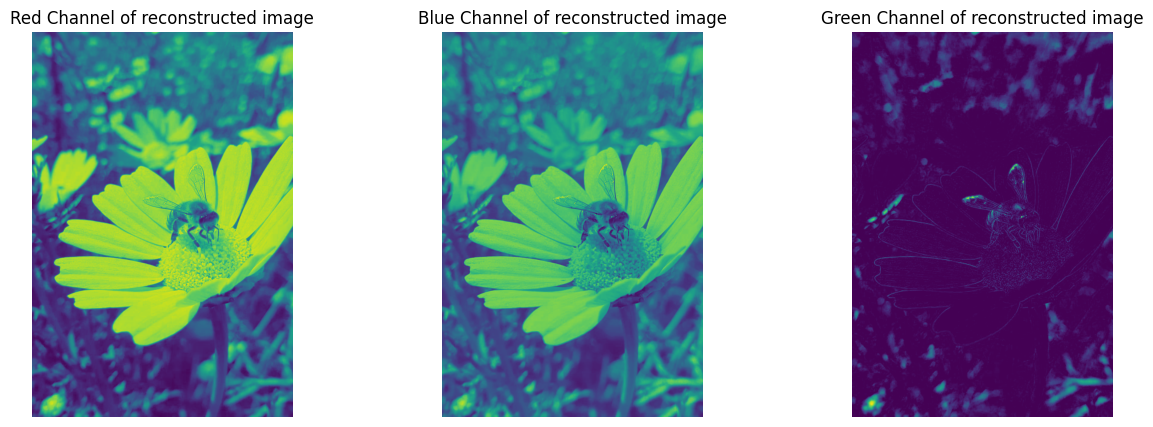

<Figure size 640x480 with 0 Axes>

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_redo[:, :, 0])
axes[0].set_title("Red Channel of reconstructed image")
axes[0].axis('off')

axes[1].imshow(img_redo[:, :, 1])
axes[1].set_title("Blue Channel of reconstructed image")
axes[1].axis('off')

axes[2].imshow(img_redo[:, :, 2])
axes[2].set_title("Green Channel of reconstructed image")
axes[2].axis('off')

plt.show()
plt.tight_layout()

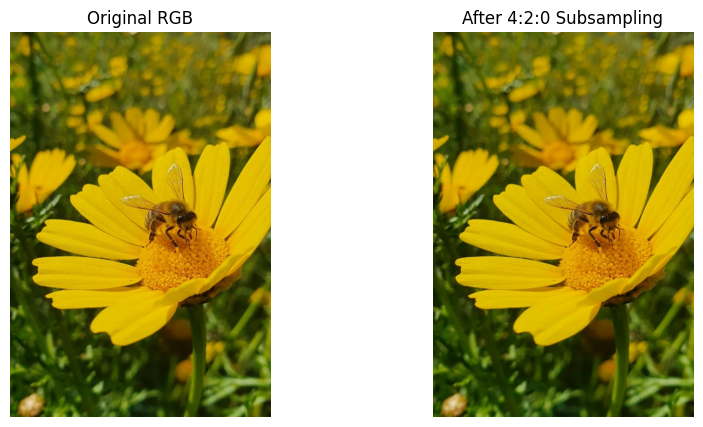

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_rgb)
axes[0].set_title('Original RGB')
axes[0].axis('off')

axes[1].imshow(img_redo.astype(np.uint8))
axes[1].set_title('After 4:2:0 Subsampling')
axes[1].axis('off')
plt.show()

**Building Blocks of a JPEG Image**

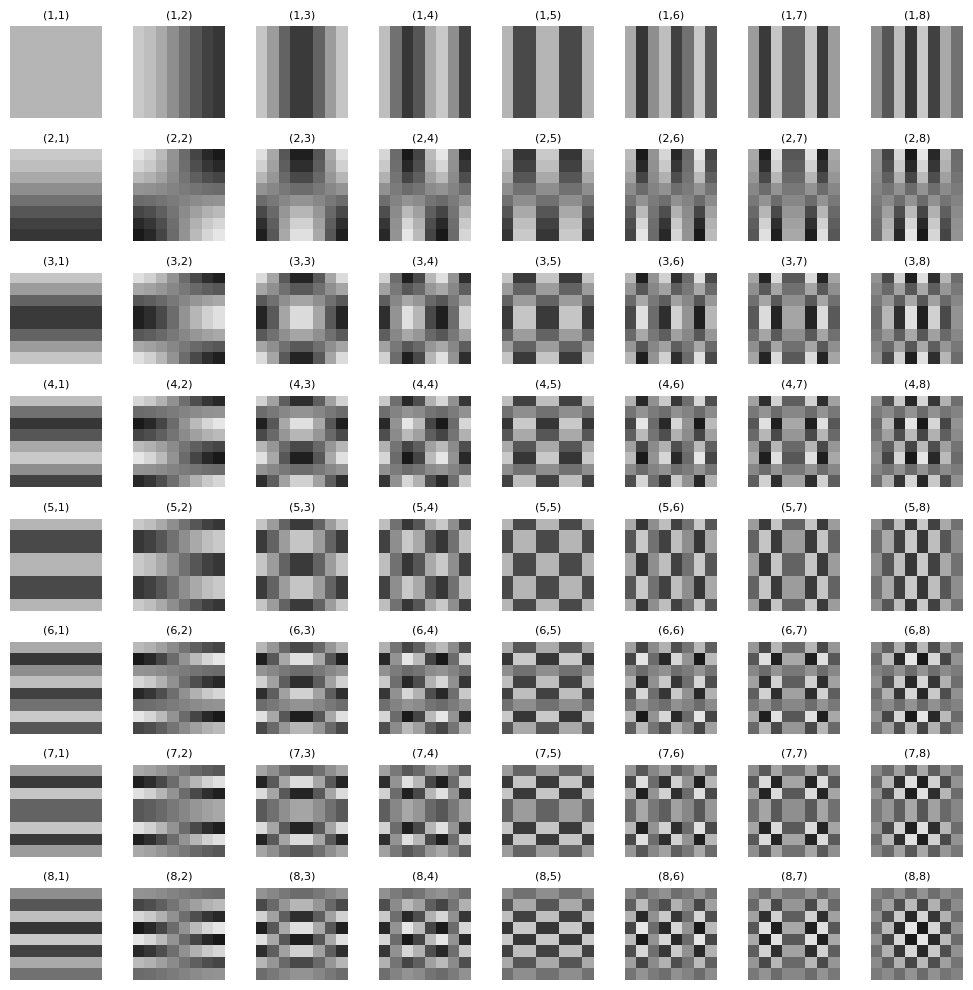

In [10]:
# dct as an orthonormal basis
def dct_basis_image(u, v, size=8):

    img = np.zeros((size, size))

    for x in range(size):
        for y in range(size):
            cu = 1.0 / np.sqrt(2) if u == 0 else 1.0
            cv = 1.0 / np.sqrt(2) if v == 0 else 1.0
            img[x, y] = 0.25 * cu * cv * np.cos((2*x+1)*u*np.pi/(2*size)) * np.cos((2*y+1)*v*np.pi/(2*size))

    return img


fig, axes = plt.subplots(8, 8, figsize=(10,10))

for u in range(8):
    for v in range(8):
        ax = axes[u, v]
        ax.imshow(dct_basis_image(u, v), cmap='gray', vmin=-0.3, vmax=0.3)
        ax.axis('off')
        ax.set_title(f'({u+1},{v+1})', fontsize=8)

plt.tight_layout()
plt.show()

In [11]:

def dct_matrix(n=8):
    A = np.zeros((n, n))
    for k in range(n):
        c = np.sqrt(1.0/n) if k == 0 else np.sqrt(2.0/n)
        for i in range(n):
            A[k, i] = c * np.cos((2*i+1) * k * np.pi / (2*n))
    return A

def dct_2d_mat(block, A):
    return A @ block @ A.T

def idct_2d_mat(coeffs, A):
    return A.T @ coeffs @ A

In [12]:
# Quantization Tables
LUM_QT = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
])

CHROM_QT = np.array([
    [17, 18, 24, 47, 99, 99, 99, 99],
    [18, 21, 26, 66, 99, 99, 99, 99],
    [24, 26, 56, 99, 99, 99, 99, 99],
    [47, 66, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99]
])

In [13]:
def scale_qt(qt, quality):

    if quality <= 0:
        quality = 1
    if quality >= 100:
        quality = 99
    if quality < 50:
        scale = 50.0 / quality
    else:
        scale = (100.0 - quality) / 50.0
    qt_scaled = np.floor(qt * scale)

    return np.clip(qt_scaled, 1, 255).astype(np.int16)


def quantize(block, qt):
    return np.round(block / qt).astype(np.int16)

def dequantize(block, qt):
    return block.astype(np.float32) * qt


In [14]:
def split_into_blocks(image, block_size=8):

    h, w = image.shape
    pad_h = (block_size - h % block_size) % block_size
    pad_w = (block_size - w % block_size) % block_size

    if pad_h or pad_w:
        image = np.pad(image, ((0, pad_h), (0, pad_w)), mode='constant')

    blocks = []
    for i in range(0, h + pad_h, block_size):
        for j in range(0, w + pad_w, block_size):
            blocks.append(image[i:i+block_size, j:j+block_size])

    return blocks, (h, w, pad_h, pad_w)

def reconstruct_from_blocks(blocks, orig_h, orig_w, pad_h, pad_w, block_size=8):

    full_h = orig_h + pad_h
    full_w = orig_w + pad_w
    img = np.zeros((full_h, full_w), dtype=blocks[0].dtype)
    idx = 0

    for i in range(0, full_h, block_size):
        for j in range(0, full_w, block_size):
            img[i:i+block_size, j:j+block_size] = blocks[idx]
            idx += 1

    return img[:orig_h, :orig_w]

In [15]:
def jpeg_compress(image_path, quality=80, return_recon=True):

    # Load image
    img = np.array(Image.open(image_path).convert('RGB'))
    h, w, _ = img.shape

    # Scale quantization tables
    lum_qt = scale_qt(LUM_QT, quality)
    chrom_qt = scale_qt(CHROM_QT, quality)

    # Convert to YCbCr
    Y, Cb, Cr = ColourSpace(img)

    # Chroma subsampling
    Cb_sub = subsample_chroma(Cb)
    Cr_sub = subsample_chroma(Cr)

    # Split into blocks
    y_blocks, y_info = split_into_blocks(Y)
    cb_blocks, cb_info = split_into_blocks(Cb_sub)
    cr_blocks, cr_info = split_into_blocks(Cr_sub)

    # DCT matrix
    A = dct_matrix(8)

    # Process Y (luminance)
    y_quant = []
    for blk in y_blocks:
        blk_f = blk.astype(np.float32) - 128  # level shift
        dct = dct_2d_mat(blk_f, A)
        q = quantize(dct, lum_qt)
        y_quant.append(q)

    # Process Cb
    cb_quant = []
    for blk in cb_blocks:
        blk_f = blk.astype(np.float32) - 128
        dct = dct_2d_mat(blk_f, A)
        q = quantize(dct, chrom_qt)
        cb_quant.append(q)

    # Process Cr
    cr_quant = []
    for blk in cr_blocks:
        blk_f = blk.astype(np.float32) - 128
        dct = dct_2d_mat(blk_f, A)
        q = quantize(dct, chrom_qt)
        cr_quant.append(q)

    if return_recon:
        # Reconstruct Y
        y_recon_blocks = []
        for q in y_quant:
            dct_recon = dequantize(q, lum_qt)
            blk = idct_2d_mat(dct_recon, A) + 128  # add back level shift
            blk = np.clip(blk, 0, 255).astype(np.uint8)
            y_recon_blocks.append(blk)
        Y_recon = reconstruct_from_blocks(y_recon_blocks, *y_info)

        # Reconstruct Cb
        cb_recon_blocks = []
        for q in cb_quant:
            dct_recon = dequantize(q, chrom_qt)
            blk = idct_2d_mat(dct_recon, A) + 128
            blk = np.clip(blk, 0, 255).astype(np.uint8)
            cb_recon_blocks.append(blk)
        Cb_recon = reconstruct_from_blocks(cb_recon_blocks, *cb_info)

        # Reconstruct Cr
        cr_recon_blocks = []
        for q in cr_quant:
            dct_recon = dequantize(q, chrom_qt)
            blk = idct_2d_mat(dct_recon, A) + 128
            blk = np.clip(blk, 0, 255).astype(np.uint8)
            cr_recon_blocks.append(blk)
        Cr_recon = reconstruct_from_blocks(cr_recon_blocks, *cr_info)

        # Upsample chroma
        Cb_up = upsample_chroma(Cb_recon, Y_recon.shape)
        Cr_up = upsample_chroma(Cr_recon, Y_recon.shape)

        # Convert back to RGB
        rgb_recon = ycbcr_to_rgb(Y_recon, Cb_up, Cr_up)
        return rgb_recon

    else:
        return {
            'y_quant': y_quant,
            'cb_quant': cb_quant,
            'cr_quant': cr_quant,
            'y_info': y_info,
            'cb_info': cb_info,
            'cr_info': cr_info,
            'quality': quality,
            'shape': (h, w)
        }


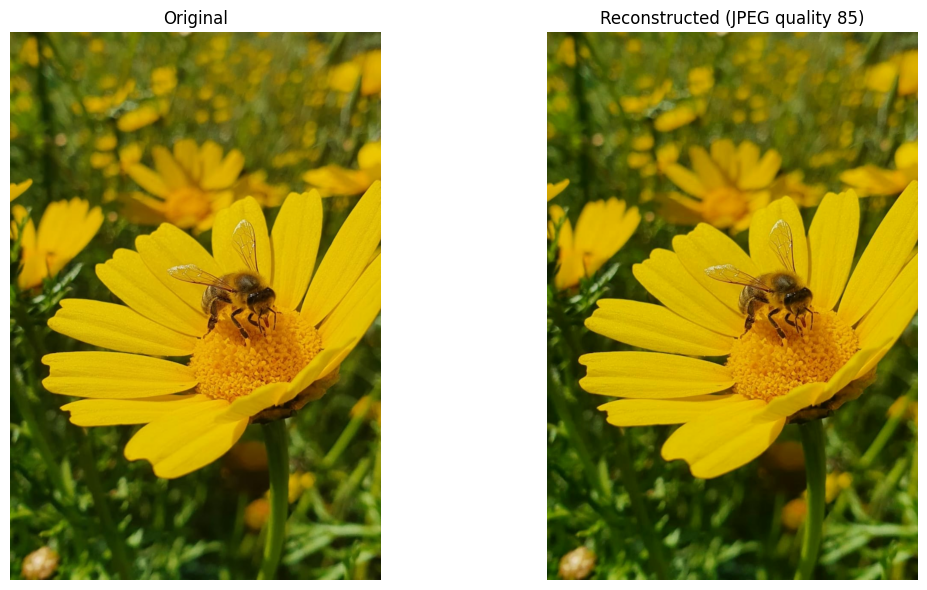

PSNR (Peak Signal To Noise Ratio): 39.18 dB


In [16]:
if __name__ == "__main__":
    image_path = "1.jpeg"

    try:
        reconstructed = jpeg_compress(image_path, quality=85, return_recon=True)

        original = np.array(Image.open(image_path).convert('RGB'))

        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(original)
        axes[0].set_title("Original")
        axes[0].axis('off')
        axes[1].imshow(reconstructed)
        axes[1].set_title("Reconstructed (JPEG quality 85)")
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()

        mse = np.mean((original.astype(float) - reconstructed.astype(float)) ** 2)
        if mse == 0:
            psnr = float('inf')
        else:
            psnr = 20 * np.log10(255.0 / np.sqrt(mse))
        print(f"PSNR (Peak Signal To Noise Ratio): {psnr:.2f} dB")

    except FileNotFoundError:
        print(f"Error: Image '{image_path}' not found. Please upload an image named '1.jpeg' or rename your images so.")